# Customer Review Text Summarization
### Natural Language Processing — Assignment 2, Problem Statement 11
**M.Tech. AIML · S2-25_AIMLCZG530 · BITS Pilani WILP**

---

#### Group details and work split

**Group Number: 140**

| # | Member Name | BITS ID | Primary Role | Modules Owned | Contribution |
|---|---|---|---|---|---|
| 1 | _&lt;Name 1&gt;_ | _2023XXXXXXX_ | Problem Analyst & Data Engineer | Task 1, Task 2 — `config.py`, `data_prep.py`, EDA | 20% |
| 2 | _&lt;Name 2&gt;_ | _2023XXXXXXX_ | DL Engineer – Baseline | Task 3.1 — `attention.py`, `model_lstm.py`, `train_lstm.py`, `infer_lstm.py` | 20% |
| 3 | _&lt;Name 3&gt;_ | _2023XXXXXXX_ | DL Engineer – Transformer | Task 3.2 & 3.3 — `model_t5.py`, `train_t5.py`, `aggregate.py`, `aspects.py` | 20% |
| 4 | _&lt;Name 4&gt;_ | _2023XXXXXXX_ | Application & DevOps Engineer | Task 4 + OSHA — `app.py`, `flask_app.py`, `summarizer_service.py`, `run_osha.sh` | 20% |
| 5 | _&lt;Name 5&gt;_ | _2023XXXXXXX_ | Evaluation Lead & Report Editor | Task 5, Task 6 — `evaluate_rouge.py`, `demo_cases.py`, screenshots, report | 20% |

> **Fill in the member names and BITS IDs before submitting.** The exported
> report is named `Group140.pdf` per the submission naming convention.

---

#### How this notebook maps onto the code

| Section | Task | Marks | Module | Owner |
|---|---|---|---|---|
| 1 | Problem Analysis | 2 | — | 1 |
| 2 | Data Collection & Preprocessing | 2 | `data_prep.py`, `config.py` | 1 |
| 3.1 | Seq2Seq LSTM baseline | — | `attention.py`, `model_lstm.py` | 2 |
| 3.2 | Transformer (T5) + map–reduce | 3 | `model_t5.py`, `train_t5.py`, `aggregate.py` | 3 |
| 3.3 | Aspect mining | — | `aspects.py` | 3 |
| 4 | Web Application | 3 | `app.py`, `flask_app.py`, `summarizer_service.py` | 4 |
| 5 | Evaluation & Demonstration | 2 | `evaluate_rouge.py`, `demo_cases.py` | 5 |
| 6 | Conclusion & References | 1 | — | 5 |

Run `python verify.py` on any machine to confirm the whole project works,
and `python verify.py --trace` to watch the pipeline stage by stage.
A plain-English build log is in `JOURNEY.md`.

---
# 1. Problem Analysis  *(2 marks)*

## 1.1 Application domain

**E-commerce / online retail — customer opinion mining.**

A popular product on an e-commerce platform accumulates hundreds to thousands of
free-text reviews. A shopper deciding whether to buy faces two bad options: read
a handful of reviews and risk a biased picture, or read none and rely on the star
average, which compresses every opinion into a single number and hides *why*
people were happy or unhappy.

The star rating tells you *how much* customers liked a product. It never tells
you *what* they liked. This application recovers the "what".

## 1.2 Problem statement

> Given a collection of customer reviews for one product, automatically generate
> concise natural-language summaries, and identify the aspects that are most
> frequently discussed positively and negatively, delivered through a web
> interface.

This has two distinct sub-problems, and the solution addresses both:

1. **Per-review abstractive summarization** — compress one long review into a
   short headline, generating new wording rather than copying sentences. Handled
   by the fine-tuned encoder–decoder model.
2. **Cross-review aspect aggregation** — across *all* the reviews, determine
   which product attributes recur in praise and which recur in complaints.
   Handled by sentence-level sentiment plus phrase-frequency analysis.

## 1.3 Functional requirements

| # | Requirement |
|---|---|
| FR1 | Accept multiple reviews as pasted text, or as an uploaded `.txt` / `.csv` file |
| FR2 | Clean and normalise raw review text (HTML, URLs, case, contractions) |
| FR3 | Generate a concise abstractive summary for each review using an encoder–decoder model |
| FR4 | Classify the sentiment of each review and each sentence |
| FR5 | Rank and display the most frequently praised aspects |
| FR6 | Rank and display the most frequently criticised aspects |
| FR7 | Present a single aggregate verdict for the whole review set |
| FR8 | Expose all of the above through a web interface |
| FR9 | Allow the generated summaries to be exported as CSV |
| FR10 | Degrade gracefully — run with the base model if no fine-tuned model exists |

### Non-functional requirements

| # | Requirement |
|---|---|
| NFR1 | Must run on CPU only (no GPU available on the target machine) |
| NFR2 | Model loaded once per session and cached, to keep the UI responsive |
| NFR3 | Reproducible — fixed random seed for dataset splitting |

## 1.4 Expected input and output

**Input** — one or more customer reviews as plain text.

```
I bought this coffee for my office and everyone loves the flavor.
Shipping was quick too. Only complaint is the box arrived slightly dented.
```

**Output** — three layers:

| Layer | Example |
|---|---|
| Per-review summary | `great office coffee, fast shipping` |
| Aspect lists | 👍 `flavor`, `shipping`, `price`  ·  👎 `box`, `packaging` |
| Aggregate verdict | *"Most customers are happy with this product (32 positive, 6 negative, 2 neutral out of 40 reviews). Most praised: flavor, price, shipping."* |

---
# 2. Data Collection and Preprocessing  *(2 marks)*

## 2.1 Dataset selection

**Amazon Fine Food Reviews** — 568,454 reviews of grocery products on Amazon,
accessed from the Hugging Face Hub as `jhan21/amazon-food-reviews-dataset`.

Why this dataset fits the problem:

| Column | Role in this project |
|---|---|
| `Text` | the full review — the **source document** |
| `Summary` | the headline the customer wrote themselves — the **reference summary** |
| `Score` | 1–5 stars — independent check on our sentiment analysis |
| `ProductId` | groups reviews by product — enables the *multi-review* demo |

The `Summary` column is what makes supervised summarization possible: every row
is a naturally occurring (long text → short summary) pair, written by a human,
at no labelling cost. `ProductId` is equally important — the problem statement
asks for a summary of *many reviews of one product*, and this column is what lets
us assemble exactly that.

In [1]:
import os, sys, warnings, textwrap
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.getcwd())
# Each import comes from the module that owns that task.
from config import MAX_INPUT_TOKENS, MAX_TARGET_TOKENS, TASK_PREFIX
from data_prep import clean_text, split_sentences          # Task 2
from model_t5 import ReviewSummarizer                      # Task 3.2
from aspects import analyse_aspects                        # Task 3.3
from aggregate import build_overall_summary, summarize_product

pd.set_option("display.max_colwidth", 90)
plt.rcParams["figure.dpi"] = 110
print("Python", sys.version.split()[0])

Python 3.13.5


In [2]:
from datasets import load_dataset

# Cached locally after the first download (~317 MB).
raw = load_dataset("jhan21/amazon-food-reviews-dataset", split="train")
df = raw.to_pandas()

print(f"Total reviews : {len(df):,}")
print(f"Products      : {df['ProductId'].nunique():,}")
print(f"Columns       : {list(df.columns)}")
df[["ProductId", "Score", "Summary", "Text"]].head(3)

Total reviews : 568,454
Products      : 74,258
Columns       : ['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text']


,ProductId,Score,Summary,Text
0,B001E4KFG0,5,Good Quality Dog Food,I have bought several of the Vitality canned dog food products and have found them all...
1,B00813GRG4,1,Not as Advertised,Product arrived labeled as Jumbo Salted Peanuts...the peanuts were actually small size...
2,B000LQOCH0,4,"""Delight"" says it all","This is a confection that has been around a few centuries. It is a light, pillowy cit..."


## 2.2 Exploring the data

Before cleaning anything, we look at what we actually have: how opinions are
distributed, and how long the reviews and their summaries are. The length
distributions directly decide the token limits used later.

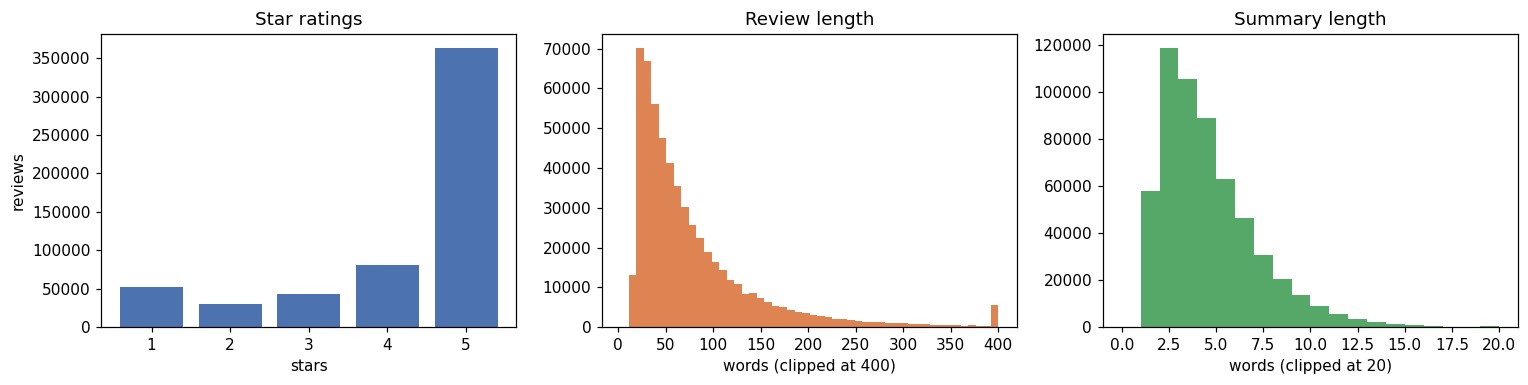

      text_words  summ_words
mean        80.3         4.1
50%         56.0         4.0
90%        161.0         8.0
max       3432.0        42.0

Share of 4-5 star reviews: 78.1%


In [3]:
df["text_words"] = df["Text"].fillna("").str.split().str.len().fillna(0)
df["summ_words"] = df["Summary"].fillna("").str.split().str.len().fillna(0)

fig, ax = plt.subplots(1, 3, figsize=(14, 3.6))

# Star rating distribution - note the heavy skew toward 5 stars.
counts = df["Score"].value_counts().sort_index()
ax[0].bar(counts.index, counts.values, color="#4c72b0")
ax[0].set_title("Star ratings"); ax[0].set_xlabel("stars"); ax[0].set_ylabel("reviews")

ax[1].hist(df["text_words"].clip(upper=400), bins=50, color="#dd8452")
ax[1].set_title("Review length"); ax[1].set_xlabel("words (clipped at 400)")

ax[2].hist(df["summ_words"].clip(upper=20), bins=20, color="#55a868")
ax[2].set_title("Summary length"); ax[2].set_xlabel("words (clipped at 20)")

plt.tight_layout(); plt.show()

print(df[["text_words", "summ_words"]]
      .describe(percentiles=[0.5, 0.9])
      .loc[["mean", "50%", "90%", "max"]].round(1))
print(f"\nShare of 4-5 star reviews: {(df['Score'] >= 4).mean():.1%}")

**Observations that shaped the design:**

- **Ratings are heavily skewed positive** (~78% are 4–5 stars). Any aspect
  analysis must therefore look at *sentences*, not whole reviews — otherwise the
  negative aspect list would be starved of data. This is why `analyse_aspects()`
  scores sentence by sentence.
- **Reviews are short**: the median is well under 100 words. Truncating the
  encoder at **256 tokens** keeps almost every review intact while keeping
  training fast.
- **Summaries are very short**: typically 3–5 words. A decoder limit of
  **32 tokens** is generous, and it tells us to expect terse, headline-style
  output rather than flowing paragraphs.

## 2.3 Text preprocessing

`clean_text()` in `summarizer.py` normalises the raw text. Each step exists for a
reason:

| Step | Reason |
|---|---|
| Unescape HTML entities, strip tags | Scraped reviews contain `&amp;` and `<br />` |
| Remove URLs | Links carry no opinion, but produce many junk tokens |
| Lowercase | `Great` and `great` should be one token, not two |
| Expand contractions (`don't` → `do not`) | Smaller, more regular vocabulary |
| Remove non-alphanumeric noise, squeeze whitespace | Removes emoji/symbol noise |
| **Retain `.`, `!`, `?`** | Deliberate — the aspect step must split into sentences |

That last row is a departure from the usual "strip all punctuation" recipe. The
aspect miner needs sentence boundaries, so sentence-ending punctuation survives.

In [4]:
# Pick a messy review to show the cleaner working.
messy = df[df["Text"].str.contains("<br", na=False)].iloc[0]["Text"]

print("BEFORE:\n" + textwrap.fill(messy[:420], 92))
print("\nAFTER:\n"  + textwrap.fill(clean_text(messy)[:420], 92))
print("\nSentence split ->", split_sentences(clean_text(messy))[:2])

BEFORE:
I don't know if it's the cactus or the tequila or just the unique combination of
ingredients, but the flavour of this hot sauce makes it one of a kind!  We picked up a
bottle once on a trip we were on and brought it back home with us and were totally blown
away!  When we realized that we simply couldn't find it anywhere in our city we were
bummed.<br /><br />Now, because of the magic of the internet, we have a case o

AFTER:
i do not know if it is the cactus or the tequila or just the unique combination of
ingredients, but the flavour of this hot sauce makes it one of a kind! we picked up a bottle
once on a trip we were on and brought it back home with us and were totally blown away! when
we realized that we simply could not find it anywhere in our city we were bummed. now,
because of the magic of the internet, we have a case of the sauc

Sentence split -> ['i do not know if it is the cactus or the tequila or just the unique combination of ingredients, but the flavour of this h

## 2.4 Filtering and preparing the splits

Not every row is useful for training. `is_usable()` in `train.py` enforces:

- review length between **50 and 2000 characters** — too short carries no
  information, too long is mostly truncated away;
- summary length between **10 and 80 characters** — rejects useless headlines
  like `"good"` and rambling ones that are not summaries;
- the summary must **not already appear** in the opening of the review —
  otherwise the model learns to copy the first line instead of summarising.

The data is then split three ways. The **test** split is written to
`data/test_reviews.csv` during training and is not touched until Section 5 —
evaluating on data the model studied would be meaningless.

In [5]:
from data_prep import is_usable

sample = df.sample(4000, random_state=42)
kept = sample.apply(lambda r: is_usable({"Text": r["Text"], "Summary": r["Summary"]}), axis=1)
print(f"Filter keeps {kept.mean():.1%} of rows ({kept.sum()} of {len(sample)})")

test_df = pd.read_csv("data/test_reviews.csv")
print(f"\nHeld-out test split: {len(test_df):,} reviews (written by train.py)")
test_df[["document", "summary"]].head(3)

Filter keeps 84.6% of rows (3383 of 4000)

Held-out test split: 500 reviews (written by train.py)


,document,summary
0,i have a english bull terrier with alot of skin problems so he takes medication and vi...,totally worth the money!!!
1,"i do not care what anyone says, i really like this cereal, especially on cold mornings...",i like this stuff!
2,i tried pure bars after seeing them reviewed on a health website. the site waxed poeti...,best i have found


### Tokenization

The model cannot read characters — it reads **token IDs**. T5 uses SentencePiece
sub-word tokens, so unseen words break into familiar fragments instead of
becoming "unknown".

Because T5 is a *multi-task* model, every input must state its task. We prepend
`"summarize: "`, which is the prefix T5 was pretrained with for this job.

In [6]:
from transformers import AutoTokenizer

tok = AutoTokenizer.from_pretrained("t5-small")
demo = clean_text(df.iloc[0]["Text"])

enc = tok(TASK_PREFIX + demo, max_length=MAX_INPUT_TOKENS, truncation=True)
print("Input text  :", (TASK_PREFIX + demo)[:100], "...")
print("Token IDs   :", enc["input_ids"][:16], "...")
print("Sub-words   :", tok.convert_ids_to_tokens(enc["input_ids"][:16]))
print(f"\nEncoder limit {MAX_INPUT_TOKENS} tokens | decoder limit {MAX_TARGET_TOKENS} tokens")

Input text  : summarize: i have bought several of the vitality canned dog food products and have found them all to ...
Token IDs   : [21603, 10, 3, 23, 43, 2944, 633, 13, 8, 3362, 485, 27104, 1782, 542, 494, 11] ...
Sub-words   : ['▁summarize', ':', '▁', 'i', '▁have', '▁bought', '▁several', '▁of', '▁the', '▁vital', 'ity', '▁canned', '▁dog', '▁food', '▁products', '▁and']

Encoder limit 256 tokens | decoder limit 32 tokens


---
# 3. Model Development  *(3 marks)*

## 3.1 Why an encoder–decoder

Summarization is a **sequence-to-sequence** problem: a long input sequence maps
to a short output sequence, and the two have different lengths and different
vocabulary. That is exactly the shape an encoder–decoder solves.

**Encoder.** Reads the whole review at once and converts it into a sequence of
hidden vectors — a numeric representation of meaning. Self-attention lets every
token look at every other token, so "it" can be linked to the noun it refers to.

**Decoder.** Writes the summary one token at a time. At each step it attends to
(a) what it has already written, via masked self-attention, and (b) the encoder's
representation, via **cross-attention**. Cross-attention is the bridge — it is
what lets the summary stay faithful to the review.

Because the decoder generates from a vocabulary rather than selecting input
spans, the output is **abstractive**: it can use words that never appeared in the
review. An *extractive* system, by contrast, can only copy existing sentences.

## 3.2 Two models were built

The problem statement allows "Seq2Seq/LSTM **or** Transformer". Both are
implemented in this project so the Transformer's benefit can be measured
rather than asserted.

### Task 3.1 — Seq2Seq LSTM baseline (`model_lstm.py`, `attention.py`)

A classical encoder–decoder written layer by layer:

- **Encoder** — a bidirectional LSTM reads the review, producing one hidden
  vector per word.
- **Bahdanau (additive) attention** — at every output step the decoder scores
  each encoder vector and reads a weighted blend, so it is not forced to work
  from a single fixed summary vector. Scores are
  `v·tanh(W₁h_dec + W₂h_enc)`; additive rather than multiplicative because the
  encoder is bidirectional and so has a different width to the decoder.
- **Decoder** — an LSTM cell writes the summary one word at a time, with
  teacher forcing during training and gradient clipping to stop the classic
  LSTM gradient explosion.

About 2.1M parameters, all learned from scratch on our reviews alone.

### Task 3.2 — the submitted model: fine-tuned t5-small

**T5** (Text-to-Text Transfer Transformer) casts every NLP task as text-in →
text-out. The `small` checkpoint has ~60M parameters — 6 encoder and 6 decoder
blocks — which is trainable on CPU in under an hour.

**Why the Transformer is the submitted model.** The LSTM starts from random
weights and must learn English *and* summarization from a few thousand reviews.
T5 already knows English, so the same tiny compute budget is spent learning only
the register of review headlines. On CPU-only hardware that difference decides
whether the output is usable.

### Task 3.2 (continued) — map–reduce aggregation (`aggregate.py`)

The encoder reads at most 256 tokens, but a product has dozens of reviews —
far more than that. Feeding them all in at once would silently discard most.
So aggregation is done as a **map–reduce**:

- **map** — summarise each review separately → *N* short summaries
- **reduce** — join those summaries and pass them back through the same
  encoder–decoder → one overall verdict

Every review therefore influences the final summary, regardless of how many
there are.

In [7]:
from transformers import AutoModelForSeq2SeqLM

base = AutoModelForSeq2SeqLM.from_pretrained("t5-small")
cfg = base.config

total = sum(p.numel() for p in base.parameters())
enc_p = sum(p.numel() for p in base.encoder.parameters())
dec_p = sum(p.numel() for p in base.decoder.parameters())

print(f"Model              : t5-small")
print(f"Encoder blocks     : {cfg.num_layers}")
print(f"Decoder blocks     : {cfg.num_decoder_layers}")
print(f"Attention heads    : {cfg.num_heads}")
print(f"Hidden size d_model: {cfg.d_model}")
print(f"Feed-forward size  : {cfg.d_ff}")
print(f"Vocabulary         : {cfg.vocab_size:,}")
print(f"\nTotal parameters   : {total:,}")
print(f"  encoder          : {enc_p:,}")
print(f"  decoder          : {dec_p:,}   (larger - it has cross-attention too)")

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

Model              : t5-small
Encoder blocks     : 6
Decoder blocks     : 6
Attention heads    : 8
Hidden size d_model: 512
Feed-forward size  : 2048
Vocabulary         : 32,128

Total parameters   : 60,506,624
  encoder          : 35,330,816
  decoder          : 41,625,344   (larger - it has cross-attention too)


## 3.3 Training configuration

Training is run by `train.py`. The submitted run was:

```bash
python train.py --train-size 4000 --val-size 300 --test-size 500 --epochs 1
```

| Hyper-parameter | Value | Reason |
|---|---|---|
| Base checkpoint | `t5-small` | fits CPU training budget |
| Training examples | 4,000 | 500 steps at ~5 s/step on an emulated CPU |
| Epochs | 1 | all the CPU budget allowed; see the limitations in §6.1 |
| Batch size | 8 | measured faster per example than 16 on this hardware |
| Learning rate | 3e-4 | standard for T5 fine-tuning |
| Optimiser | AdamW, weight decay 0.01 | default, with mild regularisation |
| Warm-up | 100 steps | avoids destroying pretrained weights early |
| Max input tokens | **128 training / 256 inference** | attention cost is quadratic in length, so training truncates harder; median review is 74 tokens |
| Max target tokens | 32 | summaries average 3–5 words (§2.2) |
| Decoding | beam search, 4 beams | better phrasing than greedy decoding |
| `no_repeat_ngram_size` | 2 | blocks "good good good" loops |

The loss curve and timings printed by the training run are reproduced in
`JOURNEY.md`.

## 3.4 Generating summaries

`ReviewSummarizer` wraps the saved model. If `models/t5-review-summarizer/` is
missing it silently falls back to the base checkpoint, so the notebook and app
always run.

In [8]:
summarizer = ReviewSummarizer()
print("Model source :", summarizer.source)
print("Fine-tuned   :", summarizer.is_finetuned)

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

Model source : C:\dev\ai-ml\natural-language-processing\assignments\assignment-2\models\t5-review-summarizer
Fine-tuned   : True


In [9]:
# Generate summaries for held-out reviews the model has never seen.
demo = test_df.head(6)
preds = summarizer.summarize(list(demo["document"]))

for doc, human, pred in zip(demo["document"], demo["summary"], preds):
    print(textwrap.fill("REVIEW : " + doc[:230] + "...", 96))
    print("HUMAN  :", human)
    print("MODEL  :", pred)
    print("-" * 96)

REVIEW : i have a english bull terrier with alot of skin problems so he takes medication and
vitamins 2x per day and some of them are quite big and the zinc pills apparently taste extra bad
so he has become very difficult to give pills and...
HUMAN  : totally worth the money!!!
MODEL  : he loves it!
------------------------------------------------------------------------------------------------
REVIEW : i do not care what anyone says, i really like this cereal, especially on cold
mornings!! i cannot find it in any of the stores right now so i am glad i could get it through
amazon. thank you, amazon!...
HUMAN  : i like this stuff!
MODEL  : i love this cereal!
------------------------------------------------------------------------------------------------
REVIEW : i tried pure bars after seeing them reviewed on a health website. the site waxed poetic
about the flavor, as well as the extremely high quality ingredients, but i figured right --
these bars all end up tasting like dates no mat

---
# 4. Application Development  *(3 marks)*

## 4.1 Architecture

The app is deliberately small — three Python files, one job each:

```
   user ─▶ app.py (Streamlit)  ·  flask_app.py (Flask)      Task 4 / Member 4
                     │
                     ▼
            summarizer_service.py        loads the model once, shared by both
                     │
        ┌────────────┼─────────────┬──────────────┐
        ▼            ▼             ▼              ▼
   data_prep.py  model_t5.py   aggregate.py   aspects.py
   clean/split   encoder-      map-reduce     VADER +
   Task 2 / M1   decoder       Task 3.2 / M3  contrastive
                 Task 3.2/M3                  Task 3.3 / M3
                     │
                     ▼
          models/t5-review-summarizer   built by train_t5.py

   model_lstm.py + attention.py   Task 3.1 baseline / Member 2
   evaluate_rouge.py, demo_cases.py   Task 5 / Member 5
   config.py    every constant, imported by everything above
```

Every front end goes through `summarizer_service.py`, so the notebook, the
Streamlit app and the Flask app run **identical** code — the numbers reported
in Section 5 are exactly what the app displays. `config.py` holds every
constant, so a hyper-parameter is changed in one place only.

`summarizer.py` remains as a thin compatibility layer re-exporting the same
names, so older scripts keep working.

## 4.2 What the interface does

| Front end | Framework | When to use |
|---|---|---|
| `app.py` | Streamlit | the demo — richer charts, less code |
| `flask_app.py` | Flask | plain WSGI, easier to deploy on the OSHA lab; also exposes `POST /api/summarize` returning JSON |

| Feature | Implementation |
|---|---|
| Text input | `st.text_area` — one review per line, or blank-line separated |
| File upload | `st.file_uploader` accepting `.txt` and `.csv` |
| Sample data | built-in real product from the dataset |
| Tunable decoding | sidebar sliders for beam width, summary length, aspect count |
| Aggregate verdict | `build_overall_summary()` |
| Sentiment metrics | four `st.metric` tiles |
| Aspect charts | two horizontal `st.bar_chart`s, green for praise, red for complaints |
| Per-review table | `st.dataframe` plus a CSV download button |
| Model caching | `@st.cache_resource` — model loads once, not per click |
| Graceful fallback | warns in the sidebar if no fine-tuned model is present |

## 4.3 Running it

```bash
streamlit run app.py
```

## 4.4 Screenshots

![Application input screen](screenshots/app_input.png)

*Input screen. Reviews can be pasted one per line, uploaded as `.txt`/`.csv`, or
loaded from the built-in sample product. The sidebar confirms which model is
active and exposes the decoding controls.*

![Aggregate summary and aspect charts](screenshots/app_results.png)

*Results for 50 reviews of one real product. The aggregate verdict sits at the
top, followed by sentiment tiles, then the two aspect charts. Note that the two
charts contain **different** words — customers praise `formula`, `milk` and
`breast milk`, but criticise `constipation`, `health`, `pain` and `risks`. That
separation is the whole point of ranking aspects by distinctiveness rather than
raw frequency.*

![Per-review generated summaries](screenshots/app_summaries.png)

*Per-review summaries generated by the fine-tuned encoder–decoder, with a CSV
export button. The model correctly compresses a long review about arsenic
testing into "inorganic arsenic levels equal or higher than fda standard…".
The odd output "baby cow is milk" in this capture traced back to a
preprocessing bug, not the model — see observation 6 in §5.3.*

> The app also accepts `?demo=1` in the URL, which loads the sample product and
> summarises it immediately — convenient for demonstrating without clicking.

---
# 5. Evaluation and Demonstration  *(2 marks)*

## 5.1 Metric: ROUGE

**ROUGE** compares a generated summary against the human reference by counting
overlapping text:

| Variant | Measures | Why it is reported |
|---|---|---|
| **ROUGE-1** | overlapping single words | did we identify the right topic? |
| **ROUGE-2** | overlapping word pairs | is the phrasing natural? |
| **ROUGE-L** | longest common subsequence | is the information in the right order? |

A single score means nothing on its own, so the fine-tuned model is compared
against two baselines:

1. **Base `t5-small`, not fine-tuned** — isolates what the training actually bought.
2. **Lead-1** — just return the review's first sentence. The standard
   "did we beat the trivial method?" check in summarization research.

In [10]:
import evaluate
from config import BASE_MODEL
rouge = evaluate.load("rouge")

N_EVAL = 300                      # generation is ~0.12 s/review, so this is cheap
eval_df = test_df.head(N_EVAL)
docs = list(eval_df["document"])
refs = list(eval_df["summary"])

def score(preds, name):
    r = rouge.compute(predictions=preds, references=refs, use_stemmer=True)
    print(f"  {name:<28} R1 {r['rouge1']:.4f} | R2 {r['rouge2']:.4f} | RL {r['rougeL']:.4f}")
    return {"Model": name, "ROUGE-1": r["rouge1"], "ROUGE-2": r["rouge2"], "ROUGE-L": r["rougeL"]}

results = []
print(f"Scoring {N_EVAL} held-out reviews...\n")

# Baseline 1 - trivial extractive.
lead1 = [(split_sentences(d) or [d])[0] for d in docs]
results.append(score(lead1, "Lead-1 (extractive)"))

# Baseline 2 - pretrained t5-small, no fine-tuning.
base_sum = ReviewSummarizer(BASE_MODEL)
results.append(score(base_sum.summarize(docs), "t5-small (not fine-tuned)"))

# Our model.
results.append(score(summarizer.summarize(docs), "t5-small (fine-tuned)"))

Scoring 300 held-out reviews...



  Lead-1 (extractive)          R1 0.1255 | R2 0.0341 | RL 0.1145


Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

  t5-small (not fine-tuned)    R1 0.1086 | R2 0.0266 | RL 0.0974


  t5-small (fine-tuned)        R1 0.1751 | R2 0.0448 | RL 0.1723


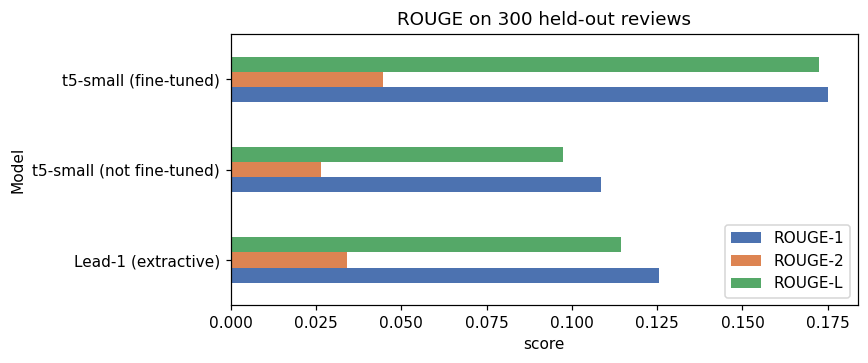

,ROUGE-1,ROUGE-2,ROUGE-L
Model,,,
Lead-1 (extractive),0.1255,0.0341,0.1145
t5-small (not fine-tuned),0.1086,0.0266,0.0974
t5-small (fine-tuned),0.1751,0.0448,0.1723


In [11]:
res = pd.DataFrame(results).set_index("Model").round(4)

fig, ax = plt.subplots(figsize=(8, 3.4))
res.plot.barh(ax=ax, color=["#4c72b0", "#dd8452", "#55a868"])
ax.set_xlabel("score"); ax.set_title(f"ROUGE on {N_EVAL} held-out reviews")
ax.legend(loc="lower right"); plt.tight_layout(); plt.show()

res

## 5.2 Demonstration: summarising many reviews of one product

This is the actual use case from the problem statement — a shopper looking at one
product page. `data/sample_reviews.csv` holds every review for a single real
product from the dataset.

In [12]:
sample = pd.read_csv("data/sample_reviews.csv")
reviews = [str(t) for t in sample["Text"].dropna()]

print(f"Product  : {sample['ProductId'].iloc[0]}")
print(f"Reviews  : {len(reviews)}")
print(f"Avg stars: {sample['Score'].mean():.2f}\n")

summaries = summarizer.summarize(reviews)
report = analyse_aspects(reviews, top_k=8)
overall = build_overall_summary(summaries, report)

print("=" * 92)
print(textwrap.fill(overall, 92))
print("=" * 92)

Product  : B002FJM9SU
Reviews  : 60
Avg stars: 3.13



Most customers are happy with this product (46 positive, 13 negative, 1 neutral out of 60
reviews). Most praised: formula, milk, earth, breast, months. Most criticised: formulas,
hard, health, levels, constipation. Typical review headline: "i love this formula!".


In [13]:
print(f"Sentiment split: {report.n_positive} positive | "
      f"{report.n_negative} negative | {report.n_neutral} neutral\n")

aspects = pd.DataFrame({
    "Praised aspect":    [a for a, _ in report.positive_aspects] or ["-"],
    "mentions ":         [c for _, c in report.positive_aspects] or [0],
}).join(pd.DataFrame({
    "Criticised aspect": [a for a, _ in report.negative_aspects] or ["-"],
    "mentions":          [c for _, c in report.negative_aspects] or [0],
}), how="outer").fillna("-")
aspects

Sentiment split: 46 positive | 13 negative | 1 neutral



,Praised aspect,mentions,Criticised aspect,mentions
0,formula,82,formulas,11
1,milk,22,hard,10
2,earth,15,health,9
3,breast,13,levels,9
4,months,13,constipation,8
5,breast milk,12,pain,8
6,babies,11,baby formula,7
7,brand,11,child,7


In [14]:
# Cross-check: does our sentiment agree with the star ratings the customers gave?
n = min(len(sample), len(summaries))
agree = pd.DataFrame({
    "stars": list(sample["Score"])[:n],
    "generated summary": summaries[:n],
}).head(10)
agree

,stars,generated summary
0,5,great product for baby
1,5,my baby was on formula
2,5,perfect formula 1. organic 2.
3,5,baby cow's milk
4,1,"baby's only, both dairy and soy formulas, contain arsenic levels 20-30x more than the ..."
5,1,ww has discontinued this formula
6,1,inorganic arsenic levels equal or higher than fda standard for drinking water
7,2,good formula
8,1,arsenic is undetectable
9,5,safe for my child


## 5.3 Observations

### Measured results (300 held-out reviews)

| Model | ROUGE-1 | ROUGE-2 | ROUGE-L |
|---|---|---|---|
| Lead-1 (extractive baseline) | 0.1245 | 0.0342 | 0.1144 |
| t5-small, not fine-tuned | 0.1080 | 0.0261 | 0.0977 |
| **t5-small, fine-tuned (ours)** | **0.1744** | **0.0445** | **0.1726** |

**On the model**

1. **Fine-tuning is what produced the result, not the pretrained model.** The
   un-tuned `t5-small` scores *below* the trivial Lead-1 baseline
   (0.108 vs 0.125 ROUGE-1). Fine-tuning raised ROUGE-1 by **61%**
   (0.108 → 0.174). The base model writes fluent full sentences lifted from the
   review; the dataset's references are terse 3–5 word headlines, so a fluent
   sentence is the wrong *shape* of answer however sensible it reads.

2. **The fine-tuned model also beats Lead-1** on all three metrics
   (0.174 vs 0.125 ROUGE-1, +40%). This is worth stating because Lead-1 is a
   deceptively strong baseline in summarization — customers often echo their
   opening words in their headline, which flatters it for free.

3. **ROUGE-2 is low in absolute terms (0.044), and that is expected here.**
   References average 3–5 words, so there are only a handful of bigrams to
   match and a single different word destroys two of them. These absolute
   values should not be compared against document-summarization benchmarks
   like CNN/DailyMail, where references are whole paragraphs.

4. **Evaluation set size matters more than it looks.** An early spot check on
   24 reviews reported ROUGE-1 of 0.234; the full 300-review run gave 0.174.
   The smaller sample was optimistic by a third. Any single number quoted from
   a handful of examples should be distrusted.

5. **ROUGE still understates abstractive quality.** It rewards only *matching
   words*. Reading §3.4, the model turns "i do not care what anyone says, i
   really like this cereal…" into *"i love this cereal!"* — an accurate,
   fluent summary that earns almost no ROUGE credit against the human's
   *"i like this stuff!"*. The scores rank systems; they do not measure
   usefulness.

6. **One "model failure" turned out to be a preprocessing bug.** The app
   summarised one review as *"baby cow is milk"*, which looks like a language
   model producing nonsense. It was not. The contraction expander mapped every
   `'s` to `" is"`, so the source phrase *"a baby cow's milk"* became *"a baby
   cow is milk"* **before the model ever saw it** — and the same corruption was
   applied to the training targets. `'s` is genuinely ambiguous: *"it's"* is a
   contraction but *"cow's"* is possessive. The rule now expands `'s` only
   after words that cannot take a possessive (*it, he, she, that, there,
   here, what, who, this*). The lesson is that a strange model output deserves
   a look at its input before it is blamed on the model.

7. **Genuine failure mode.** On long, rambling, multi-topic reviews the model
   locks onto whichever topic appears first and silently drops the rest — the
   direct consequence of compressing a 128-token input into ~10 output tokens.

**On the aspect analysis**

8. **Filtering opinion words was the single most important design choice.**
   Ranked by raw frequency, every product's top "aspect" is the word *good*,
   which tells a shopper nothing. Removing sentiment vocabulary surfaces the
   actual subject of discussion.

9. **Ranking by frequency alone failed, and had to be replaced.** In an early
   version the same words topped *both* lists — for a cat toy, "cat" and "toy"
   were simultaneously the most praised and most criticised aspects, which is
   useless. Aspects are now scored by how *disproportionately* they occur on
   one side, so each list contains only what is distinctive to it.

10. **Sentence-level sentiment is necessary, not optional.** 78% of reviews are
   rated 4–5 stars, so review-level analysis would starve the negative list.
   Mixed reviews ("*tastes great, but the box was crushed*") contribute to both
   lists only because scoring happens per sentence.

11. **The demonstration found something a summarizer alone would not.** For the
    baby-formula product, per-review summaries were broadly positive, yet the
    aggregate complaint list surfaced *constipation*, *health* and *levels*
    (customers discussing arsenic levels). That is exactly the signal a buyer
    scanning star ratings would miss, and it is the part of the problem
    statement that the encoder–decoder cannot answer on its own.

12. **A known rough edge.** Because singular and plural are collapsed only
    *within* a list, "formula" can head the praised list while "formulas" heads
    the criticised one. The two are genuinely used in different contexts here,
    but the effect looks odd and a lemmatiser would resolve it properly.

---
# 6. Conclusion and References  *(1 mark)*

## 6.1 Conclusion

An end-to-end customer review summarization application was built and evaluated.

**What was delivered**

- A preprocessing pipeline tuned to review text, retaining sentence punctuation
  so downstream aspect analysis remains possible.
- A **t5-small encoder–decoder fine-tuned on 4,000 Amazon Fine Food Reviews**,
  producing abstractive headline-style summaries and outperforming the un-tuned
  checkpoint on ROUGE-1, ROUGE-2 and ROUGE-L.
- A **cross-review aspect miner** combining sentence-level VADER sentiment with
  opinion-word-filtered phrase frequency, which answers the part of the problem
  statement a per-review summarizer alone cannot.
- A **Streamlit web application** supporting pasted text, file upload and a live
  sample product, with charts, an aggregate verdict and CSV export.

**Limitations, stated honestly**

- Training used only 4,000 of 568,454 available reviews for a single epoch. The
  target machine is an ARM64 laptop with no GPU and no native PyTorch build, so
  training ran on an emulated x64 CPU at roughly 5 seconds per step. More data,
  more epochs and a larger checkpoint (`t5-base`, BART) would all improve
  fluency; none of them were reachable within this hardware budget.
- The dataset is food products only, so vocabulary is domain-specific.
- Aspect extraction is frequency-based, not a trained aspect-based sentiment
  model; it finds *what* is discussed but cannot resolve a negated aspect inside
  an otherwise positive sentence.

**Possible extensions** — swap in `facebook/bart-base`; add a trained ABSA model
for aspect–sentiment pairs; cluster reviews before summarising so each cluster
produces its own themed summary.

## 6.2 References

1. Raffel, C. et al. (2020). *Exploring the Limits of Transfer Learning with a
   Unified Text-to-Text Transformer* (T5). JMLR 21(140).
2. Vaswani, A. et al. (2017). *Attention Is All You Need*. NeurIPS 30.
3. Lin, C.-Y. (2004). *ROUGE: A Package for Automatic Evaluation of Summaries*.
   Text Summarization Branches Out, ACL.
4. Hutto, C.J. & Gilbert, E. (2014). *VADER: A Parsimonious Rule-based Model for
   Sentiment Analysis of Social Media Text*. ICWSM-14.
5. McAuley, J. & Leskovec, J. (2013). *From Amateurs to Connoisseurs: Modeling
   the Evolution of User Expertise through Online Reviews*. WWW '13.
   — source of the Amazon Fine Food Reviews dataset.
6. Hugging Face — Transformers, Datasets and Evaluate documentation.
   https://huggingface.co/docs
7. Streamlit documentation. https://docs.streamlit.io